# **TikTok Project**
**Course 4 - Regression Analysis: Simplify complex data relationships**

**Author:** Ahmad Daniel  
**Date:** May 2026

You are a data professional at TikTok. The data team is working towards building a machine learning model that can be used to determine whether a video contains a claim or whether it offers an opinion. With a successful prediction model, TikTok can reduce the backlog of user reports and prioritize them more efficiently.

The team is getting closer to completing the project, having completed an initial plan of action, initial Python coding work, EDA, and hypothesis testing.

The TikTok team has reviewed the results of the hypothesis testing. TikTok's Operations Lead, Maika Abadi, is interested in how different variables are associated with whether a user is verified. Earlier, the data team observed that if a user is verified, they are much more likely to post opinions. Now, the data team has decided to explore how to predict verified status to help them understand how video characteristics relate to verified users. Therefore, you have been asked to conduct a logistic regression using verified status as the outcome variable. The results may be used to inform the final model related to predicting whether a video is a claim vs an opinion.

A notebook was structured and prepared to help you in this project. Please complete the following questions.

# **Course 4 End-of-course project: Regression modeling**

In this activity, you will build a logistic regression model in Python. As you have learned, logistic regression helps you estimate the probability of an outcome. For data science professionals, this is a useful skill because it allows you to consider more than one variable against the variable you're measuring against. This opens the door for much more thorough and flexible analysis to be completed.

**The purpose** of this project is to demonstrate knowledge of EDA and regression models.

**The goal** is to build a logistic regression model and evaluate the model.

*This activity has three parts:*

**Part 1:** EDA & Checking Model Assumptions
* What are some purposes of EDA before constructing a logistic regression model?

**Part 2:** Model Building and Evaluation
* What resources do you find yourself using as you complete this stage?

**Part 3:** Interpreting Model Results
* What key insights emerged from your model(s)?
* What business recommendations do you propose based on the models built?

# **Build a regression model**

## **PACE: Plan**
Consider the questions in your PACE Strategy Document to reflect on the Plan stage.

### **Task 1. Imports and loading**
Import the data and packages that you've learned are needed for building regression models.

In [1]:
# Import packages for data manipulation
import pandas as pd
import numpy as np

# Import packages for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Import packages for data preprocessing
from sklearn.preprocessing import OneHotEncoder
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.utils import resample

# Import packages for data modeling
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [2]:
# Load dataset into dataframe
data = pd.read_csv("tiktok_dataset.csv")

## **PACE: Analyze**

Consider the questions in your PACE Strategy Document to reflect on the Analyze stage.

In this stage, consider the following question where applicable to complete your code response:

* What are some purposes of EDA before constructing a logistic regression model?

**Response:**

The purposes of EDA before constructing a logistic regression model are

1) to identify data anomalies such as outliers and class imbalance that might affect the modeling;

2) to verify model assumptions such as no severe multicollinearity.

### **Task 2a. Explore data with EDA**

Analyze the data and check for and handle missing values and duplicates.

Inspect the first five rows of the dataframe.

In [3]:
# Display first few rows
data.head()

,#,claim_status,video_id,video_duration_sec,video_transcription_text,verified_status,author_ban_status,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count
0,1,claim,8762575920,14,someone shared with me that an average human c...,not verified,under scrutiny,587292.0,53354.0,16958.0,812.0,234.0
1,2,claim,3611525817,59,someone shared with me that microbes from the ...,not verified,active,785464.0,156452.0,616.0,2878.0,1852.0
2,3,claim,5070975780,11,someone shared with me that 20% of the world's...,not verified,banned,999949.0,562158.0,35841.0,445.0,236.0
3,4,claim,7233352528,50,someone shared with me that the number of busi...,not verified,active,365084.0,49164.0,6122.0,372.0,25.0
4,5,claim,3387873230,55,someone shared with me that the total number o...,verified,active,672207.0,203409.0,57134.0,4253.0,1253.0


In [4]:
# Get number of rows and columns
data.shape

(19382, 12)

In [5]:
# Get data types of columns
data.dtypes

#                             int64
claim_status                 object
video_id                      int64
video_duration_sec            int64
video_transcription_text     object
verified_status              object
author_ban_status            object
video_view_count            float64
video_like_count            float64
video_share_count           float64
video_download_count        float64
video_comment_count         float64
dtype: object

In [6]:
# Get basic information
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19382 entries, 0 to 19381
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   #                         19382 non-null  int64  
 1   claim_status              19182 non-null  object 
 2   video_id                  19382 non-null  int64  
 3   video_duration_sec        19382 non-null  int64  
 4   video_transcription_text  19182 non-null  object 
 5   verified_status           19382 non-null  object 
 6   author_ban_status         19382 non-null  object 
 7   video_view_count          19182 non-null  float64
 8   video_like_count          19182 non-null  float64
 9   video_share_count         19182 non-null  float64
 10  video_download_count      19182 non-null  float64
 11  video_comment_count       19182 non-null  float64
dtypes: float64(5), int64(3), object(4)
memory usage: 1.8+ MB


In [7]:
# Generate basic descriptive stats
data.describe()

,#,video_id,video_duration_sec,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count
count,19382.000000,1.938200e+04,19382.000000,19182.000000,19182.000000,19182.000000,19182.000000,19182.000000
mean,9691.500000,5.605640e+09,32.455061,253763.179856,83234.815243,16522.990929,1034.953498,341.892138
std,5595.245794,2.530172e+09,16.155484,320836.905107,131588.832099,31720.266661,1992.411530,776.994082
min,1.000000,1.234730e+09,5.000000,21.000000,0.000000,0.000000,0.000000,0.000000
25%,4846.250000,3.421425e+09,18.250000,4966.000000,836.250000,118.000000,7.000000,1.000000
50%,9691.500000,5.595368e+09,32.000000,9980.500000,3531.500000,742.000000,47.000000,10.000000
75%,14536.750000,7.798543e+09,46.000000,502163.000000,123078.000000,18042.000000,1141.750000,278.000000
max,19382.000000,9.999935e+09,60.000000,999976.000000,656081.000000,239681.000000,15278.000000,7887.000000


In [8]:
# Check for missing values
data.isna().sum()

#                             0
claim_status                200
video_id                      0
video_duration_sec            0
video_transcription_text    200
verified_status               0
author_ban_status             0
video_view_count            200
video_like_count            200
video_share_count           200
video_download_count        200
video_comment_count         200
dtype: int64

In [9]:
# Drop rows with missing values
data = data.dropna(axis=0)

In [10]:
# Display first few rows after handling missing values
data.head()

,#,claim_status,video_id,video_duration_sec,video_transcription_text,verified_status,author_ban_status,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count
0,1,claim,8762575920,14,someone shared with me that an average human c...,not verified,under scrutiny,587292.0,53354.0,16958.0,812.0,234.0
1,2,claim,3611525817,59,someone shared with me that microbes from the ...,not verified,active,785464.0,156452.0,616.0,2878.0,1852.0
2,3,claim,5070975780,11,someone shared with me that 20% of the world's...,not verified,banned,999949.0,562158.0,35841.0,445.0,236.0
3,4,claim,7233352528,50,someone shared with me that the number of busi...,not verified,active,365084.0,49164.0,6122.0,372.0,25.0
4,5,claim,3387873230,55,someone shared with me that the total number o...,verified,active,672207.0,203409.0,57134.0,4253.0,1253.0


In [11]:
# Check for duplicates
data.duplicated().sum()

np.int64(0)

**Note:** There does not seem to be any duplicates.

Check for and handle outliers.

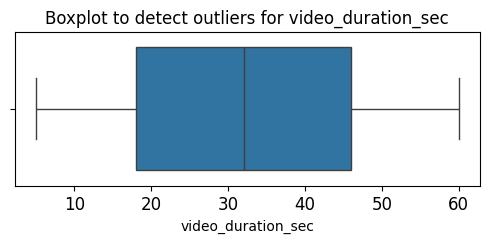

In [12]:
# Create a boxplot to visualize distribution of `video_duration_sec`
plt.figure(figsize=(6,2))
plt.title('Boxplot to detect outliers for video_duration_sec', fontsize=12)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
sns.boxplot(x=data['video_duration_sec'])
plt.show()

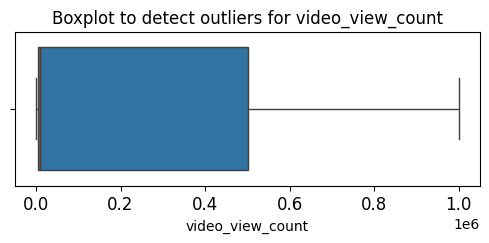

In [13]:
# Create a boxplot to visualize distribution of `video_view_count`
plt.figure(figsize=(6,2))
plt.title('Boxplot to detect outliers for video_view_count', fontsize=12)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
sns.boxplot(x=data['video_view_count'])
plt.show()

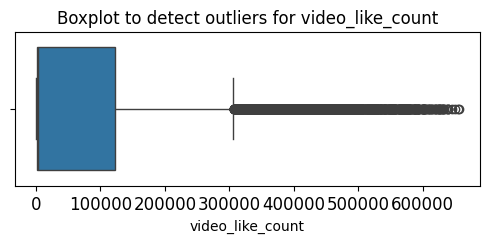

In [14]:
# Create a boxplot to visualize distribution of `video_like_count`
plt.figure(figsize=(6,2))
plt.title('Boxplot to detect outliers for video_like_count', fontsize=12)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
sns.boxplot(x=data['video_like_count'])
plt.show()

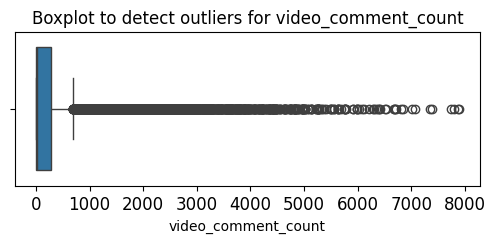

In [15]:
# Create a boxplot to visualize distribution of `video_comment_count`
plt.figure(figsize=(6,2))
plt.title('Boxplot to detect outliers for video_comment_count', fontsize=12)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
sns.boxplot(x=data['video_comment_count'])
plt.show()

In [16]:
# Check for and handle outliers for video_like_count
percentile25 = data["video_like_count"].quantile(0.25)
percentile75 = data["video_like_count"].quantile(0.75)
iqr = percentile75 - percentile25
upper_limit = percentile75 + 1.5 * iqr
data.loc[data["video_like_count"] > upper_limit, "video_like_count"] = upper_limit

In [17]:
# Check for and handle outliers for video_comment_count
percentile25 = data["video_comment_count"].quantile(0.25)
percentile75 = data["video_comment_count"].quantile(0.75)
iqr = percentile75 - percentile25
upper_limit = percentile75 + 1.5 * iqr
data.loc[data["video_comment_count"] > upper_limit, "video_comment_count"] = upper_limit

Check class balance of the target variable. Remember, the goal is to predict whether the user of a given post is verified or unverified.

In [18]:
# Check class balance
data["verified_status"].value_counts(normalize=True)

verified_status
not verified    0.939787
verified        0.060213
Name: proportion, dtype: float64

Approximately 94% of the dataset represents videos posted by unverified accounts and 6% represents videos posted by verified accounts. So the outcome variable is not very balanced.

In [19]:
# Use resampling to create class balance in the outcome variable

# Identify data points from majority and minority classes
data_majority = data[data["verified_status"] == "not verified"]
data_minority = data[data["verified_status"] == "verified"]

# Upsample the minority class (which is "verified")
data_minority_upsampled = resample(data_minority,
                                   replace=True,
                                   n_samples=len(data_majority),
                                   random_state=0)

# Combine majority class with upsampled minority class
data_upsampled = pd.concat([data_majority, data_minority_upsampled]).reset_index(drop=True)

# Display new class counts
data_upsampled["verified_status"].value_counts()

verified_status
not verified    18027
verified        18027
Name: count, dtype: int64

In [20]:
# Get the average `video_transcription_text` length for verified and unverified accounts
data_upsampled[["verified_status", "video_transcription_text"]].groupby(by="verified_status")[["video_transcription_text"]].agg(func=lambda array: np.mean([len(text) for text in array]))

,video_transcription_text
verified_status,
not verified,89.202474
verified,85.185721


In [21]:
# Extract the length of each `video_transcription_text` and add this as a column to the dataframe
data_upsampled["text_length"] = data_upsampled["video_transcription_text"].apply(func=lambda text: len(text))

In [22]:
# Display first few rows of dataframe after adding new column
data_upsampled.head()

,#,claim_status,video_id,video_duration_sec,video_transcription_text,verified_status,author_ban_status,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count,text_length
0,1,claim,8762575920,14,someone shared with me that an average human c...,not verified,under scrutiny,587292.0,53354.000,16958.0,812.0,234.0,122
1,2,claim,3611525817,59,someone shared with me that microbes from the ...,not verified,active,785464.0,156452.000,616.0,2878.0,693.5,91
2,3,claim,5070975780,11,someone shared with me that 20% of the world's...,not verified,banned,999949.0,306440.625,35841.0,445.0,236.0,87
3,4,claim,7233352528,50,someone shared with me that the number of busi...,not verified,active,365084.0,49164.000,6122.0,372.0,25.0,128
4,6,claim,8923444940,58,someone shared with me that the first electric...,not verified,active,352918.0,85281.000,32888.0,843.0,422.0,74


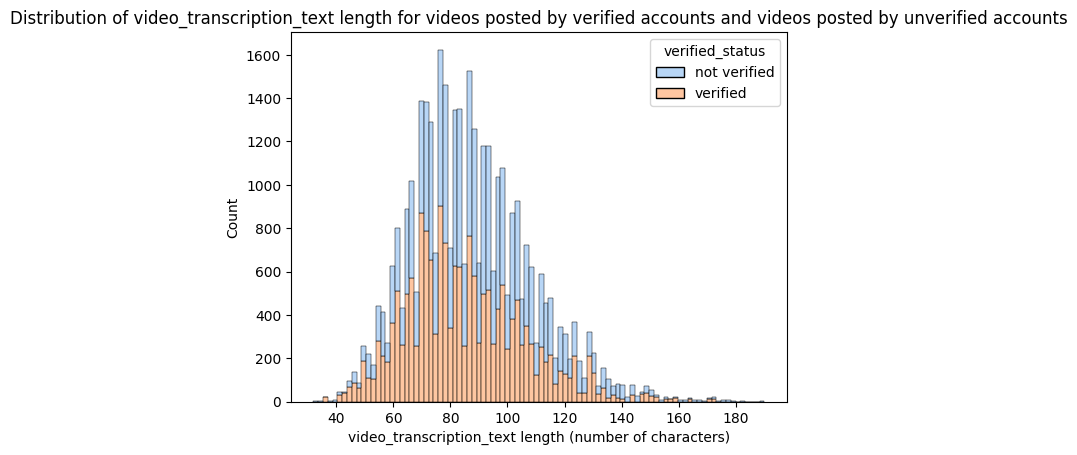

In [23]:
# Visualize the distribution of `video_transcription_text` length for verified and unverified accounts
sns.histplot(data=data_upsampled, stat="count", multiple="stack", x="text_length",
             kde=False, palette="pastel", hue="verified_status", element="bars", legend=True)
plt.title("Seaborn Stacked Histogram")
plt.xlabel("video_transcription_text length (number of characters)")
plt.ylabel("Count")
plt.title("Distribution of video_transcription_text length for videos posted by verified accounts and videos posted by unverified accounts")
plt.show()

### **Task 2b. Examine correlations**

Next, code a correlation matrix to help determine most correlated variables.

In [24]:
# Code a correlation matrix to help determine most correlated variables
data_upsampled.corr(numeric_only=True)

,#,video_id,video_duration_sec,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count,text_length
#,1.000000,0.006322,0.011746,-0.696149,-0.624712,-0.491684,-0.490617,-0.613532,-0.197764
video_id,0.006322,1.000000,0.010507,-0.002243,-0.006725,-0.008071,-0.015800,-0.020270,-0.007238
video_duration_sec,0.011746,0.010507,1.000000,-0.008012,-0.011418,-0.007767,-0.009822,-0.005378,0.001441
video_view_count,-0.696149,-0.002243,-0.008012,1.000000,0.854645,0.697296,0.699750,0.748722,0.231701
video_like_count,-0.624712,-0.006725,-0.011418,0.854645,1.000000,0.816665,0.819651,0.815413,0.215759
video_share_count,-0.491684,-0.008071,-0.007767,0.697296,0.816665,1.000000,0.711946,0.651692,0.172733
video_download_count,-0.490617,-0.015800,-0.009822,0.699750,0.819651,0.711946,1.000000,0.788697,0.164909
video_comment_count,-0.613532,-0.020270,-0.005378,0.748722,0.815413,0.651692,0.788697,1.000000,0.211996
text_length,-0.197764,-0.007238,0.001441,0.231701,0.215759,0.172733,0.164909,0.211996,1.000000


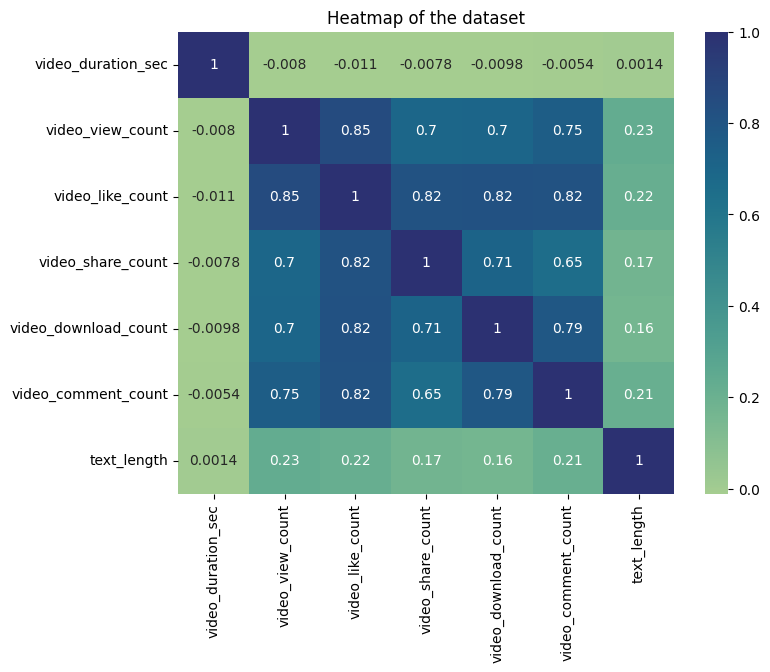

In [25]:
# Create a heatmap to visualize how correlated variables are
plt.figure(figsize=(8, 6))
sns.heatmap(
    data_upsampled[["video_duration_sec", "claim_status", "author_ban_status",
                    "video_view_count", "video_like_count", "video_share_count",
                    "video_download_count", "video_comment_count", "text_length"]]
    .corr(numeric_only=True),
    annot=True,
    cmap="crest")
plt.title("Heatmap of the dataset")
plt.show()

One of the model assumptions for logistic regression is no severe multicollinearity among the features. Take this into consideration as you examine the heatmap and choose which features to proceed with.

**Response:** The above heatmap shows that the following pair of variables are strongly correlated: `video_view_count` and `video_like_count` (high correlation coefficient).

One of the model assumptions for logistic regression is no severe multicollinearity among the features. To build a logistic regression model that meets this assumption, you could exclude `video_like_count`. And among the variables that quantify video metrics, you could keep `video_view_count`, `video_share_count`, `video_download_count`, and `video_comment_count` as features.

## **PACE: Construct**

After analysis and deriving variables with close relationships, it is time to begin constructing the model.

### **Task 3a. Select variables**

Set your Y and X variables.

Select the outcome variable.

In [26]:
# Select outcome variable
y = data_upsampled["verified_status"]

In [27]:
# Select features
X = data_upsampled[["video_duration_sec", "claim_status", "author_ban_status",
                     "video_view_count", "video_share_count",
                     "video_download_count", "video_comment_count"]]

# Display first few rows of features dataframe
X.head()

,video_duration_sec,claim_status,author_ban_status,video_view_count,video_share_count,video_download_count,video_comment_count
0,14,claim,under scrutiny,587292.0,16958.0,812.0,234.0
1,59,claim,active,785464.0,616.0,2878.0,693.5
2,11,claim,banned,999949.0,35841.0,445.0,236.0
3,50,claim,active,365084.0,6122.0,372.0,25.0
4,58,claim,active,352918.0,32888.0,843.0,422.0


**Note:** The `#` and `video_id` columns are not selected as features here, because they do not seem to be helpful for predicting verified status. Also, `video_like_count` is not selected as a feature here, because it is strongly correlated with other features, as discussed earlier. Logistic regression has a no multicollinearity model assumption that needs to be met.

### **Task 3b. Train-test split**

Split the data into training and testing sets.

In [28]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)

In [29]:
# Get shape of each training and testing set
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((27040, 7), (9014, 7), (27040,), (9014,))

**Note:**
- The number of features (7) aligns between the training and testing sets.
- The number of rows aligns between the features and the outcome variable for training and testing.

### **Task 3c. Encode variables**

Check the data types of the features.

In [30]:
# Check data types
X_train.dtypes

video_duration_sec        int64
claim_status             object
author_ban_status        object
video_view_count        float64
video_share_count       float64
video_download_count    float64
video_comment_count     float64
dtype: object

In [31]:
# Get unique values in `claim_status`
X_train["claim_status"].unique()

array(['opinion', 'claim'], dtype=object)

In [32]:
# Get unique values in `author_ban_status`
X_train["author_ban_status"].unique()

array(['banned', 'active', 'under scrutiny'], dtype=object)

As shown above, the `claim_status` and `author_ban_status` features are each of data type `object` currently. In order to work with the implementations of models through `sklearn`, these categorical features will need to be made numeric. One way to do this is through one-hot encoding.

Encode categorical features in the training set using an appropriate method.

In [33]:
# Select the training features that needs to be encoded
X_train_to_encode = X_train[["claim_status", "author_ban_status"]]

# Display first few rows
X_train_to_encode.head()

,claim_status,author_ban_status
33014,opinion,banned
15880,opinion,active
30404,opinion,active
1155,claim,active
5088,claim,active


In [34]:
# Set up an encoder for one-hot encoding the categorical features
X_encoder = OneHotEncoder(drop='first', sparse_output=False)

In [35]:
# Fit and transform the training features using the encoder
X_train_encoded = X_encoder.fit_transform(X_train_to_encode)

In [36]:
# Get feature names from encoder
X_encoder.get_feature_names_out()

array(['claim_status_opinion', 'author_ban_status_banned',
       'author_ban_status_under scrutiny'], dtype=object)

In [37]:
# Display first few rows of encoded training features
X_train_encoded

array([[1., 1., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       ...,
       [1., 0., 0.],
       [1., 0., 0.],
       [0., 1., 0.]], shape=(27040, 3))

In [38]:
# Place encoded training features into a dataframe
X_train_encoded_df = pd.DataFrame(data=X_train_encoded, columns=X_encoder.get_feature_names_out())

# Display first few rows
X_train_encoded_df.head()

,claim_status_opinion,author_ban_status_banned,author_ban_status_under scrutiny
0,1.0,1.0,0.0
1,1.0,0.0,0.0
2,1.0,0.0,0.0
3,0.0,0.0,0.0
4,0.0,0.0,0.0


In [39]:
# Display first few rows of `X_train` with `claim_status` and `author_ban_status` columns dropped
X_train.drop(columns=["claim_status", "author_ban_status"]).head()

,video_duration_sec,video_view_count,video_share_count,video_download_count,video_comment_count
33014,26,1054.0,51.0,0.0,0.0
15880,55,2038.0,114.0,6.0,0.0
30404,55,2864.0,67.0,6.0,0.0
1155,9,58495.0,3424.0,74.0,1.0
5088,18,696765.0,57493.0,2117.0,470.0


In [40]:
# Concatenate `X_train` and `X_train_encoded_df` to form the final dataframe for training data
X_train_final = pd.concat([X_train.drop(columns=["claim_status", "author_ban_status"]).reset_index(drop=True), X_train_encoded_df], axis=1)

# Display first few rows
X_train_final.head()

,video_duration_sec,video_view_count,video_share_count,video_download_count,video_comment_count,claim_status_opinion,author_ban_status_banned,author_ban_status_under scrutiny
0,26,1054.0,51.0,0.0,0.0,1.0,1.0,0.0
1,55,2038.0,114.0,6.0,0.0,1.0,0.0,0.0
2,55,2864.0,67.0,6.0,0.0,1.0,0.0,0.0
3,9,58495.0,3424.0,74.0,1.0,0.0,0.0,0.0
4,18,696765.0,57493.0,2117.0,470.0,0.0,0.0,0.0


In [41]:
# Check data type of outcome variable
y_train.dtype

dtype('O')

In [42]:
# Get unique values of outcome variable
y_train.unique()

array(['verified', 'not verified'], dtype=object)

In [43]:
# Set up an encoder for one-hot encoding the categorical outcome variable
y_encoder = OneHotEncoder(drop='first', sparse_output=False)

In [44]:
# Encode the training outcome variable
y_train_final = y_encoder.fit_transform(y_train.values.reshape(-1, 1)).ravel()

# Display the encoded training outcome variable
y_train_final

array([1., 0., 1., ..., 1., 1., 0.], shape=(27040,))

### **Task 3d. Model building**

Construct a model and fit it to the training set.

In [45]:
# Construct a logistic regression model and fit it to the training set
log_clf = LogisticRegression(random_state=0, max_iter=800).fit(X_train_final, y_train_final)

## **PACE: Execute**

Consider the questions in your PACE Strategy Document to reflect on the Execute stage.

### **Task 4a. Results and evaluation**

Evaluate your model.

Encode categorical features in the testing set using an appropriate method.

In [46]:
# Select the testing features that needs to be encoded
X_test_to_encode = X_test[["claim_status", "author_ban_status"]]

# Display first few rows
X_test_to_encode.head()

,claim_status,author_ban_status
27207,opinion,active
17763,opinion,active
22904,opinion,active
35576,opinion,active
8229,claim,under scrutiny


In [47]:
# Transform the testing features using the encoder
X_test_encoded = X_encoder.transform(X_test_to_encode)

# Display first few rows of encoded testing features
X_test_encoded

array([[1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       ...,
       [1., 0., 0.],
       [0., 0., 0.],
       [0., 1., 0.]], shape=(9014, 3))

In [48]:
# Place encoded testing features into a dataframe
X_test_encoded_df = pd.DataFrame(data=X_test_encoded, columns=X_encoder.get_feature_names_out())

# Display first few rows
X_test_encoded_df.head()

,claim_status_opinion,author_ban_status_banned,author_ban_status_under scrutiny
0,1.0,0.0,0.0
1,1.0,0.0,0.0
2,1.0,0.0,0.0
3,1.0,0.0,0.0
4,0.0,0.0,1.0


In [49]:
# Display first few rows of `X_test` with `claim_status` and `author_ban_status` columns dropped
X_test.drop(columns=["claim_status", "author_ban_status"]).head()

,video_duration_sec,video_view_count,video_share_count,video_download_count,video_comment_count
27207,12,9653.0,1581.0,34.0,10.0
17763,60,346.0,27.0,3.0,0.0
22904,5,4565.0,44.0,1.0,0.0
35576,49,6832.0,405.0,52.0,12.0
8229,52,874660.0,7652.0,2708.0,683.0


In [50]:
# Concatenate `X_test` and `X_test_encoded_df` to form the final dataframe for testing data
X_test_final = pd.concat([X_test.drop(columns=["claim_status", "author_ban_status"]).reset_index(drop=True), X_test_encoded_df], axis=1)

# Display first few rows
X_test_final.head()

,video_duration_sec,video_view_count,video_share_count,video_download_count,video_comment_count,claim_status_opinion,author_ban_status_banned,author_ban_status_under scrutiny
0,12,9653.0,1581.0,34.0,10.0,1.0,0.0,0.0
1,60,346.0,27.0,3.0,0.0,1.0,0.0,0.0
2,5,4565.0,44.0,1.0,0.0,1.0,0.0,0.0
3,49,6832.0,405.0,52.0,12.0,1.0,0.0,0.0
4,52,874660.0,7652.0,2708.0,683.0,0.0,0.0,1.0


In [51]:
# Use the logistic regression model to get predictions on the encoded testing set
y_pred = log_clf.predict(X_test_final)

In [52]:
# Display the predictions on the encoded testing set
y_pred

array([1., 1., 1., ..., 1., 0., 0.], shape=(9014,))

In [53]:
# Display the true labels of the testing set
y_test

27207        verified
17763    not verified
22904        verified
35576        verified
8229     not verified
             ...     
11183    not verified
24209        verified
34123        verified
4566     not verified
6161     not verified
Name: verified_status, Length: 9014, dtype: object

In [54]:
# Encode the testing outcome variable
y_test_final = y_encoder.transform(y_test.values.reshape(-1, 1)).ravel()

# Display the encoded testing outcome variable
y_test_final

array([1., 0., 1., ..., 1., 0., 0.], shape=(9014,))

In [55]:
# Get shape of each training and testing set
X_train_final.shape, y_train_final.shape, X_test_final.shape, y_test_final.shape

((27040, 8), (27040,), (9014, 8), (9014,))

**Note:**
- The number of features (8) aligns between the training and testing sets.
- The number of rows aligns between the features and the outcome variable for training and testing.

### **Task 4b. Visualize model results**

Create a confusion matrix to visualize the results of the logistic regression model.

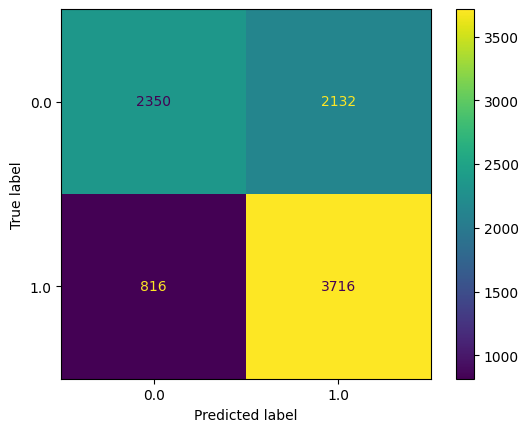

In [56]:
# Compute values for confusion matrix
log_cm = confusion_matrix(y_test_final, y_pred, labels=log_clf.classes_)

# Create display of confusion matrix
log_disp = ConfusionMatrixDisplay(confusion_matrix=log_cm, display_labels=log_clf.classes_)

# Plot confusion matrix
log_disp.plot()

# Display plot
plt.show()

In [57]:
# Calculate accuracy manually
(2350 + 3716) / (2350 + 2132 + 816 + 3716)

0.6729531839360994

**Confusion matrix interpretation:**

- Upper-left quadrant (True Negatives): videos posted by unverified accounts that the model accurately classified as so.
- Upper-right quadrant (False Positives): videos posted by unverified accounts that the model misclassified as posted by verified accounts.
- Lower-left quadrant (False Negatives): videos posted by verified accounts that the model misclassified as posted by unverified accounts.
- Lower-right quadrant (True Positives): videos posted by verified accounts that the model accurately classified as so.

A perfect model would yield all true negatives and true positives, and no false negatives or false positives.

In [58]:
# Create classification report for logistic regression model
target_labels = ["verified", "not verified"]
print(classification_report(y_test_final, y_pred, target_names=target_labels))

              precision    recall  f1-score   support

    verified       0.74      0.52      0.61      4482
not verified       0.64      0.82      0.72      4532

    accuracy                           0.67      9014
   macro avg       0.69      0.67      0.67      9014
weighted avg       0.69      0.67      0.67      9014



**Note:** The classification report above shows that the logistic regression model achieved a precision of 64% and a recall of 82% for the 'not verified' class, and it achieved an overall accuracy of 67%. Note that the precision and recall scores are taken from the 'not verified' row of the output because that is the target class that we are most interested in predicting.

### **Task 4c. Interpret model coefficients**

In [59]:
# Get the feature names from the model and the model coefficients (log-odds ratios)
pd.DataFrame(data={"Feature Name": log_clf.feature_names_in_, "Model Coefficient": log_clf.coef_[0]})

,Feature Name,Model Coefficient
0,video_duration_sec,1.417344e-03
1,video_view_count,-2.272483e-07
2,video_share_count,1.480204e-07
3,video_download_count,-8.366014e-06
4,video_comment_count,7.347027e-04
5,claim_status_opinion,1.845698e+00
6,author_ban_status_banned,4.148067e-02
7,author_ban_status_under scrutiny,-2.026375e-01


### **Task 4d. Conclusion**

1. What are the key takeaways from this project?
2. What results can be presented from this project?

**Response:**

Key takeaways:

- The dataset has a few strongly correlated variables, which might lead to multicollinearity issues when fitting a logistic regression model. We decided to drop `video_like_count` from the model building.
- Based on the logistic regression model, `claim_status_opinion` has the largest coefficient (1.85), indicating that opinion videos are strongly associated with verified accounts.
- The logistic regression model had not great, but acceptable predictive power: a precision of 64% is less than ideal, but a recall of 82% is very good. Overall accuracy is 67%, towards the lower end of what would typically be considered acceptable.

We developed a logistic regression model for verified status based on video features. The model had decent predictive power. Based on the estimated model coefficients from the logistic regression, videos with opinion claim status tend to be strongly associated with higher odds of the user being verified. Other video features have small estimated coefficients in the model, so their association with verified status seems to be small.